# Phase 1 — EDA & Preprocessing
## Dataset 1: FIFA 21 | Dataset 2: EPL Matches
> รัน cell ตามลำดับ วาง `fifa21_raw.csv` และ `epl_raw.csv` ใน `../data/raw/` ก่อน

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')
os.makedirs('../data/processed', exist_ok=True)
print('Libraries loaded ✓')

Libraries loaded ✓


---
## 🔵 PART 1: FIFA 21 — Player Position Classification

In [2]:
# โหลดข้อมูล FIFA 21
df = pd.read_csv('../data/raw/fifa21_raw.csv', low_memory=False)
print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
df.head(3)

Shape: (18979, 77)
Columns: ['ID', 'Name', 'LongName', 'photoUrl', 'playerUrl', 'Nationality', 'Age', '↓OVA', 'POT', 'Club', 'Contract', 'Positions', 'Height', 'Weight', 'Preferred Foot', 'BOV', 'Best Position', 'Joined', 'Loan Date End', 'Value', 'Wage', 'Release Clause', 'Attacking', 'Crossing', 'Finishing', 'Heading Accuracy', 'Short Passing', 'Volleys', 'Skill', 'Dribbling', 'Curve', 'FK Accuracy', 'Long Passing', 'Ball Control', 'Movement', 'Acceleration', 'Sprint Speed', 'Agility', 'Reactions', 'Balance', 'Power', 'Shot Power', 'Jumping', 'Stamina', 'Strength', 'Long Shots', 'Mentality', 'Aggression', 'Interceptions', 'Positioning', 'Vision', 'Penalties', 'Composure', 'Defending', 'Marking', 'Standing Tackle', 'Sliding Tackle', 'Goalkeeping', 'GK Diving', 'GK Handling', 'GK Kicking', 'GK Positioning', 'GK Reflexes', 'Total Stats', 'Base Stats', 'W/F', 'SM', 'A/W', 'D/W', 'IR', 'PAC', 'SHO', 'PAS', 'DRI', 'DEF', 'PHY', 'Hits']


,ID,Name,LongName,photoUrl,playerUrl,Nationality,Age,↓OVA,POT,Club,...,A/W,D/W,IR,PAC,SHO,PAS,DRI,DEF,PHY,Hits
0,158023,L. Messi,Lionel Messi,https://cdn.sofifa.com/players/158/023/21_60.png,http://sofifa.com/player/158023/lionel-messi/2...,Argentina,33,93,93,\n\n\n\nFC Barcelona,...,Medium,Low,5 ★,85,92,91,95,38,65,771
1,20801,Cristiano Ronaldo,C. Ronaldo dos Santos Aveiro,https://cdn.sofifa.com/players/020/801/21_60.png,http://sofifa.com/player/20801/c-ronaldo-dos-s...,Portugal,35,92,92,\n\n\n\nJuventus,...,High,Low,5 ★,89,93,81,89,35,77,562
2,200389,J. Oblak,Jan Oblak,https://cdn.sofifa.com/players/200/389/21_60.png,http://sofifa.com/player/200389/jan-oblak/210006/,Slovenia,27,91,93,\n\n\n\nAtlético Madrid,...,Medium,Medium,3 ★,87,92,78,90,52,90,150


In [3]:
# EDA: ภาพรวม
print('=== Data Types ===')
print(df.dtypes.value_counts())

print('\n=== Missing Values (Top 20) ===')
missing = df.isnull().sum().sort_values(ascending=False)
print(missing[missing > 0].head(20))

print('\n=== Best Position Distribution ===')
pos_col = 'Best Position' if 'Best Position' in df.columns else 'Position'
print(df[pos_col].value_counts().head(20))

=== Data Types ===
int64     54
object    23
Name: count, dtype: int64

=== Missing Values (Top 20) ===
Loan Date End    17966
Hits              2595
dtype: int64

=== Best Position Distribution ===
Best Position
CB     3686
ST     2680
CAM    2299
GK     2075
RM     1611
CDM    1445
LB     1086
RB     1079
CM     1047
LM      871
RW      298
RWB     277
LWB     261
LW      186
CF       78
Name: count, dtype: int64


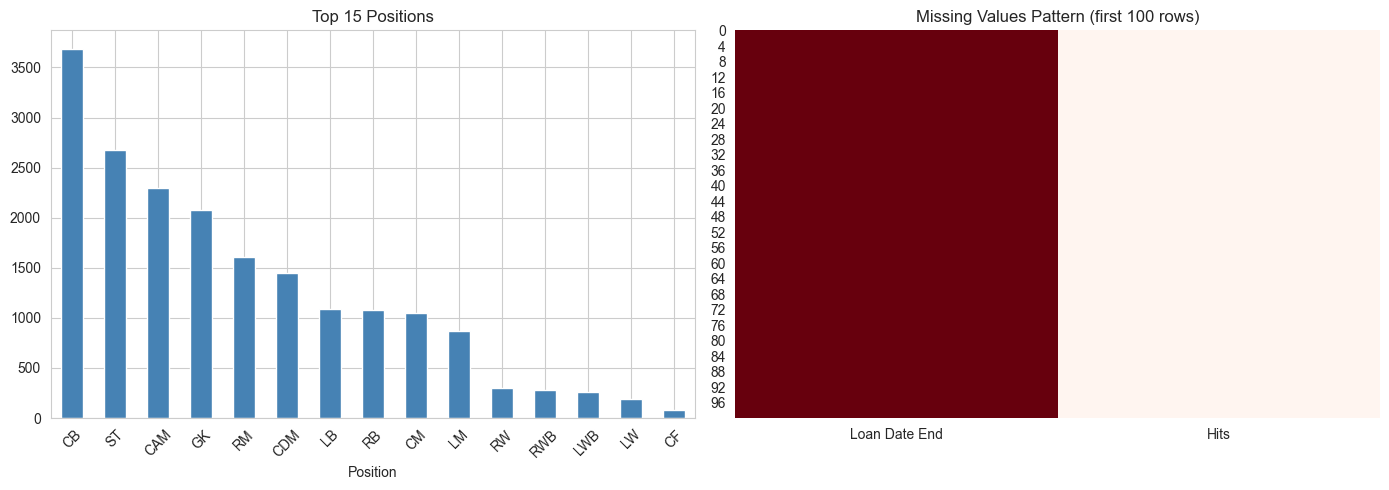

In [4]:
# Visualize: Position Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pos_col = 'Best Position' if 'Best Position' in df.columns else 'Position'
df[pos_col].value_counts().head(15).plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Top 15 Positions')
axes[0].set_xlabel('Position')
axes[0].tick_params(axis='x', rotation=45)

# Missing Values Heatmap
top_missing_cols = missing[missing > 0].head(15).index.tolist()
if top_missing_cols:
    sns.heatmap(df[top_missing_cols].isnull().astype(int).head(100),
                cmap='Reds', ax=axes[1], cbar=False)
    axes[1].set_title('Missing Values Pattern (first 100 rows)')

plt.tight_layout()
plt.show()

In [5]:
# Step 1: แปลง Height เป็น cm
def parse_height(h):
    h = str(h).strip()
    if 'cm' in h:
        return float(h.replace('cm', '').strip())
    elif "'" in h:
        parts = re.split(r"['\"]", h)
        feet = int(parts[0]) if parts[0].strip() else 0
        inches = int(parts[1]) if len(parts) > 1 and parts[1].strip() else 0
        return round(feet * 30.48 + inches * 2.54, 1)
    try:
        return float(h)
    except:
        return np.nan

df['Height'] = df['Height'].apply(parse_height)
print(f'Height range: {df["Height"].min():.1f} - {df["Height"].max():.1f} cm')
print(f'Height nulls: {df["Height"].isnull().sum()}')

Height range: 155.0 - 206.0 cm
Height nulls: 0


In [6]:
# Step 2: แปลง Weight เป็น kg
def parse_weight(w):
    w = str(w).strip()
    if 'kg' in w:
        return float(w.replace('kg', '').strip())
    elif 'lbs' in w:
        return round(float(w.replace('lbs', '').strip()) * 0.453592, 1)
    try:
        return float(w)
    except:
        return np.nan

df['Weight'] = df['Weight'].apply(parse_weight)
print(f'Weight range: {df["Weight"].min():.1f} - {df["Weight"].max():.1f} kg')
print(f'Weight nulls: {df["Weight"].isnull().sum()}')

Weight range: 50.0 - 110.0 kg
Weight nulls: 0


In [7]:
# Step 3: แปลง Value / Wage / Release Clause
def parse_money(val):
    val = str(val).replace('\u20ac', '').strip()
    if val in ['', 'nan', 'None', '0', 'N/A']:
        return 0.0
    try:
        if 'M' in val:
            return float(val.replace('M', '').strip()) * 1_000_000
        elif 'K' in val:
            return float(val.replace('K', '').strip()) * 1_000
        return float(val)
    except:
        return 0.0

for col in ['Value', 'Wage', 'Release Clause']:
    if col in df.columns:
        df[col] = df[col].apply(parse_money)
        print(f'{col}: min={df[col].min():.0f}, max={df[col].max():.0f}')

Value: min=0, max=185500000
Wage: min=0, max=560000
Release Clause: min=0, max=203100000


In [8]:
# Step 4: ลบสัญลักษณ์ ★ ออกจาก W/F, SM, IR
for col in ['W/F', 'SM', 'IR']:
    if col in df.columns:
        df[col] = (df[col].astype(str)
                   .str.replace('\u2605', '', regex=False)  # ★
                   .str.replace('★', '', regex=False)
                   .str.strip())
        df[col] = pd.to_numeric(df[col], errors='coerce')
        print(f'{col}: {df[col].unique()}')

W/F: [4 3 5 2 1]
SM: [4 5 1 2 3]
IR: [5 3 4 2 1]


In [9]:
# Step 5: จัดการ Contract column
if 'Contract' in df.columns:
    def parse_contract(c):
        c = str(c).strip()
        if 'Free' in c:
            return 'Free'
        elif 'Loan' in c or 'loan' in c:
            return 'Loan'
        elif any(sep in c for sep in ['~', ' - ', '~']):
            return 'Contract'
        elif re.search(r'\d{4}', c):
            return 'Contract'
        return 'Unknown'

    df['Contract_Status'] = df['Contract'].apply(parse_contract)
    print('Contract Status Distribution:')
    print(df['Contract_Status'].value_counts())

Contract Status Distribution:
Contract_Status
Contract    17729
Loan         1013
Free          237
Name: count, dtype: int64


Position Group Distribution:
Position_Group
MID    7273
DEF    6389
FWD    3242
GK     2075
Name: count, dtype: int64
NaN: 0


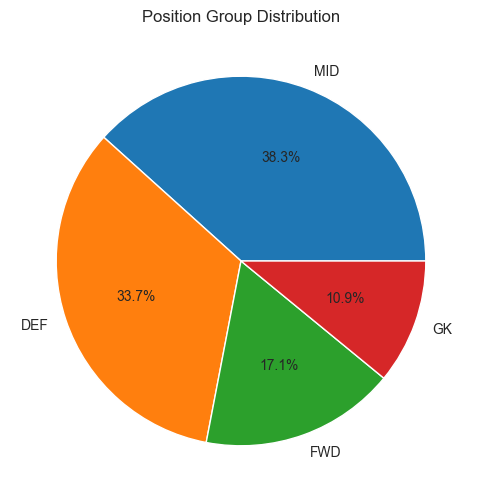

In [10]:
# Step 6: สร้าง Position_Group (Target Variable)
GK_POS  = {'GK'}
DEF_POS = {'CB', 'LB', 'RB', 'LWB', 'RWB', 'SW', 'WB'}
MID_POS = {'CM', 'CAM', 'CDM', 'LM', 'RM', 'DM', 'AM', 'LAM', 'RAM', 'LDM', 'RDM'}
FWD_POS = {'ST', 'CF', 'LW', 'RW', 'SS', 'LS', 'RS', 'LF', 'RF'}

def get_position_group(pos):
    pos = str(pos).strip().upper()
    if pos in GK_POS:  return 'GK'
    if pos in DEF_POS: return 'DEF'
    if pos in MID_POS: return 'MID'
    if pos in FWD_POS: return 'FWD'
    # Partial match fallback
    if 'GK' in pos:  return 'GK'
    if any(p in pos for p in DEF_POS): return 'DEF'
    if any(p in pos for p in MID_POS): return 'MID'
    if any(p in pos for p in FWD_POS): return 'FWD'
    return np.nan

pos_col = 'Best Position' if 'Best Position' in df.columns else 'Position'
df['Position_Group'] = df[pos_col].apply(get_position_group)

print('Position Group Distribution:')
print(df['Position_Group'].value_counts())
print(f'NaN: {df["Position_Group"].isnull().sum()}')

df['Position_Group'].value_counts().plot(kind='pie', autopct='%1.1f%%',
    title='Position Group Distribution', figsize=(6, 6))
plt.ylabel('')
plt.show()

In [11]:
# Step 7: เลือก Features และ Handle Missing Values
STAT_COLS  = ['Age', 'OVA', 'POT', 'Height', 'Weight', 'Value', 'Wage', 'W/F', 'SM', 'IR']
ATTR_COLS  = ['PAC', 'SHO', 'PAS', 'DRI', 'DEF', 'PHY']
feature_cols = [c for c in STAT_COLS + ATTR_COLS if c in df.columns]
print(f'Features selected ({len(feature_cols)}): {feature_cols}')

# สร้าง clean dataframe
df_clean = df[feature_cols + ['Position_Group']].copy()
df_clean = df_clean.dropna(subset=['Position_Group'])
print(f'After drop NaN target: {df_clean.shape}')

# Impute median สำหรับ numeric columns
for col in feature_cols:
    null_count = df_clean[col].isnull().sum()
    if null_count > 0:
        median_val = df_clean[col].median()
        df_clean[col] = df_clean[col].fillna(median_val)
        print(f'  Filled {col}: {null_count} nulls → median={median_val:.2f}')

print(f'\nFinal shape: {df_clean.shape}')
print(f'Remaining nulls: {df_clean.isnull().sum().sum()}')

Features selected (15): ['Age', 'POT', 'Height', 'Weight', 'Value', 'Wage', 'W/F', 'SM', 'IR', 'PAC', 'SHO', 'PAS', 'DRI', 'DEF', 'PHY']
After drop NaN target: (18979, 16)

Final shape: (18979, 16)
Remaining nulls: 0


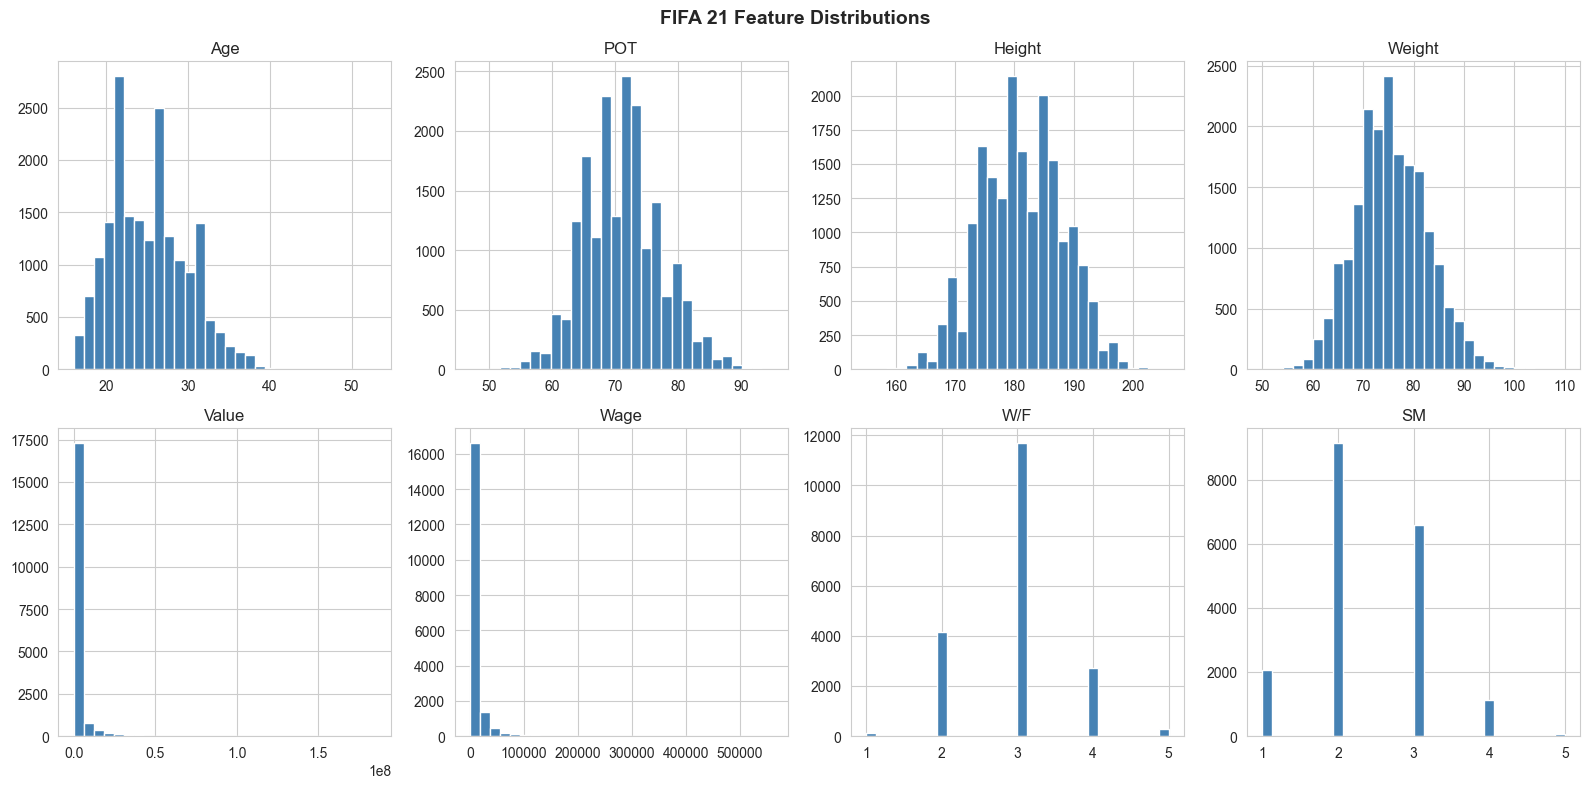

In [12]:
# Step 8: Feature Distribution Visualization
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
cols_to_plot = feature_cols[:8]
for ax, col in zip(axes.flatten(), cols_to_plot):
    df_clean[col].hist(bins=30, ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(col)
plt.suptitle('FIFA 21 Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [13]:
# Step 9: Train / Val / Test Split (70 / 15 / 15)
le_fifa = LabelEncoder()
y = le_fifa.fit_transform(df_clean['Position_Group'])
X = df_clean[feature_cols]

print(f'Class mapping: {dict(zip(le_fifa.classes_, le_fifa.transform(le_fifa.classes_)))}')

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print(f'Train : {X_train.shape} | {pd.Series(y_train).value_counts().to_dict()}')
print(f'Val   : {X_val.shape}   | {pd.Series(y_val).value_counts().to_dict()}')
print(f'Test  : {X_test.shape}  | {pd.Series(y_test).value_counts().to_dict()}')

Class mapping: {'DEF': np.int64(0), 'FWD': np.int64(1), 'GK': np.int64(2), 'MID': np.int64(3)}
Train : (13285, 15) | {3: 5091, 0: 4472, 1: 2269, 2: 1453}
Val   : (2847, 15)   | {3: 1091, 0: 958, 1: 487, 2: 311}
Test  : (2847, 15)  | {3: 1091, 0: 959, 1: 486, 2: 311}


In [14]:
# Step 10: บันทึก Clean Data และ Splits
df_clean.to_csv('../data/processed/fifa21_clean.csv', index=False)
print('✓ Saved: ../data/processed/fifa21_clean.csv')

splits_fifa = {
    'X_train': X_train, 'X_val': X_val, 'X_test': X_test,
    'y_train': y_train, 'y_val': y_val, 'y_test': y_test,
    'feature_cols': feature_cols,
    'label_encoder': le_fifa
}
joblib.dump(splits_fifa, '../data/processed/fifa21_splits.pkl')
print('✓ Saved: ../data/processed/fifa21_splits.pkl')

✓ Saved: ../data/processed/fifa21_clean.csv
✓ Saved: ../data/processed/fifa21_splits.pkl


---
## 🟠 PART 2: EPL Matches — Match Result Classification

In [15]:
# โหลดข้อมูล EPL
# Dataset อาจมีหลายไฟล์ (รายฤดูกาล) หรือ 1 ไฟล์รวม
import glob

epl_single = '../data/raw/epl_raw.csv'
if os.path.exists(epl_single):
    df_epl = pd.read_csv(epl_single, low_memory=False)
else:
    # ลองโหลดทุกไฟล์ CSV แล้ว concat
    all_csv = glob.glob('../data/raw/*.csv')
    epl_files = [f for f in all_csv if 'fifa' not in f.lower()]
    dfs = []
    for f in epl_files:
        try:
            dfs.append(pd.read_csv(f, low_memory=False))
        except Exception as e:
            print(f'Warning: {f} - {e}')
    df_epl = pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()

print(f'EPL Shape: {df_epl.shape}')
print(f'Columns: {df_epl.columns.tolist()}')
df_epl.head(3)

EPL Shape: (380, 106)
Columns: ['Div', 'Date', 'Time', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR', 'HTHG', 'HTAG', 'HTR', 'Referee', 'HS', 'AS', 'HST', 'AST', 'HF', 'AF', 'HC', 'AC', 'HY', 'AY', 'HR', 'AR', 'B365H', 'B365D', 'B365A', 'BWH', 'BWD', 'BWA', 'IWH', 'IWD', 'IWA', 'PSH', 'PSD', 'PSA', 'WHH', 'WHD', 'WHA', 'VCH', 'VCD', 'VCA', 'MaxH', 'MaxD', 'MaxA', 'AvgH', 'AvgD', 'AvgA', 'B365>2.5', 'B365<2.5', 'P>2.5', 'P<2.5', 'Max>2.5', 'Max<2.5', 'Avg>2.5', 'Avg<2.5', 'AHh', 'B365AHH', 'B365AHA', 'PAHH', 'PAHA', 'MaxAHH', 'MaxAHA', 'AvgAHH', 'AvgAHA', 'B365CH', 'B365CD', 'B365CA', 'BWCH', 'BWCD', 'BWCA', 'IWCH', 'IWCD', 'IWCA', 'PSCH', 'PSCD', 'PSCA', 'WHCH', 'WHCD', 'WHCA', 'VCCH', 'VCCD', 'VCCA', 'MaxCH', 'MaxCD', 'MaxCA', 'AvgCH', 'AvgCD', 'AvgCA', 'B365C>2.5', 'B365C<2.5', 'PC>2.5', 'PC<2.5', 'MaxC>2.5', 'MaxC<2.5', 'AvgC>2.5', 'AvgC<2.5', 'AHCh', 'B365CAHH', 'B365CAHA', 'PCAHH', 'PCAHA', 'MaxCAHH', 'MaxCAHA', 'AvgCAHH', 'AvgCAHA']


,Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,...,AvgC<2.5,AHCh,B365CAHH,B365CAHA,PCAHH,PCAHA,MaxCAHH,MaxCAHA,AvgCAHH,AvgCAHA
0,E0,12/09/2020,12:30,Fulham,Arsenal,0,3,A,0,1,...,1.84,0.75,2.01,1.89,2.02,1.91,2.13,1.92,2.02,1.87
1,E0,12/09/2020,15:00,Crystal Palace,Southampton,1,0,H,1,0,...,1.70,0.25,1.78,2.13,1.79,2.17,1.85,2.18,1.79,2.12
2,E0,12/09/2020,17:30,Liverpool,Leeds,4,3,H,3,2,...,2.62,-1.50,1.85,2.05,1.85,2.08,1.90,2.16,1.84,2.04


In [16]:
# EDA: Missing Values รายฤดูกาล
print('=== EPL Missing Values ===')
missing_epl = df_epl.isnull().sum().sort_values(ascending=False)
print(missing_epl[missing_epl > 0])

# ดู distribution ของ columns หลัก
if 'FTR' in df_epl.columns:
    print('\n=== Full Time Result ===')
    print(df_epl['FTR'].value_counts())

=== EPL Missing Values ===
Series([], dtype: int64)

=== Full Time Result ===
FTR
A    153
H    144
D     83
Name: count, dtype: int64


FTR Distribution:
FTR
A    153
H    144
D     83
Name: count, dtype: int64


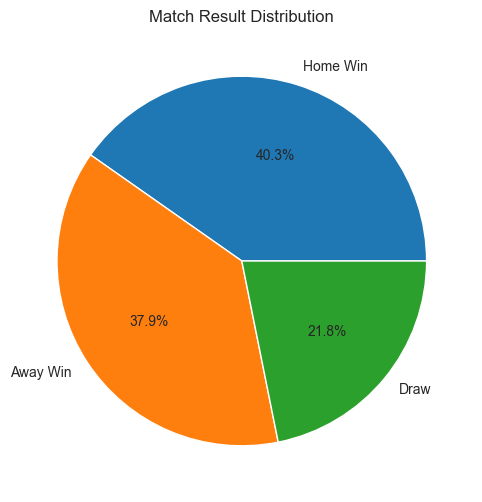

In [17]:
# สร้าง target column: FTR (Full Time Result)
if 'FTR' not in df_epl.columns:
    if 'FTHG' in df_epl.columns and 'FTAG' in df_epl.columns:
        df_epl['FTR'] = df_epl.apply(
            lambda row: 'H' if row['FTHG'] > row['FTAG']
                        else ('A' if row['FTHG'] < row['FTAG'] else 'D'), axis=1)
    else:
        # หา result column อื่น
        result_candidates = [c for c in df_epl.columns if 'result' in c.lower() or 'ftr' in c.lower()]
        if result_candidates:
            df_epl.rename(columns={result_candidates[0]: 'FTR'}, inplace=True)

print('FTR Distribution:')
print(df_epl['FTR'].value_counts())

df_epl['FTR'].value_counts().plot(kind='pie', autopct='%1.1f%%',
    title='Match Result Distribution', figsize=(6, 6),
    labels=['Home Win', 'Away Win', 'Draw'])
plt.ylabel('')
plt.show()

In [18]:
# เลือก Features
ALL_EPL_FEATURES = ['FTHG', 'FTAG', 'HS', 'AS', 'HST', 'AST',
                    'HC', 'AC', 'HF', 'AF', 'HY', 'AY', 'HR', 'AR']
epl_features = [c for c in ALL_EPL_FEATURES if c in df_epl.columns]
print(f'Available features ({len(epl_features)}): {epl_features}')

df_clean_epl = df_epl[epl_features + ['FTR']].copy()
df_clean_epl = df_clean_epl.dropna(subset=['FTR'])
print(f'After drop NaN target: {df_clean_epl.shape}')

# Handle missing values ด้วย mean imputation
for col in epl_features:
    null_count = df_clean_epl[col].isnull().sum()
    if null_count > 0:
        mean_val = df_clean_epl[col].mean()
        df_clean_epl[col] = df_clean_epl[col].fillna(mean_val)
        print(f'  Filled {col}: {null_count} nulls → mean={mean_val:.2f}')

Available features (14): ['FTHG', 'FTAG', 'HS', 'AS', 'HST', 'AST', 'HC', 'AC', 'HF', 'AF', 'HY', 'AY', 'HR', 'AR']
After drop NaN target: (380, 15)


In [19]:
# Feature Engineering
df_clean_epl['goal_diff'] = df_clean_epl['FTHG'] - df_clean_epl['FTAG']

if 'HS' in df_clean_epl.columns and 'HST' in df_clean_epl.columns:
    df_clean_epl['home_shot_acc'] = df_clean_epl['HST'] / (df_clean_epl['HS'] + 1)
    df_clean_epl['away_shot_acc'] = df_clean_epl['AST'] / (df_clean_epl['AS'] + 1)

if 'HC' in df_clean_epl.columns and 'AC' in df_clean_epl.columns:
    df_clean_epl['corner_diff'] = df_clean_epl['HC'] - df_clean_epl['AC']

if 'HF' in df_clean_epl.columns and 'AF' in df_clean_epl.columns:
    df_clean_epl['foul_diff']  = df_clean_epl['HF'] - df_clean_epl['AF']

ENGINEERED = ['goal_diff', 'home_shot_acc', 'away_shot_acc', 'corner_diff', 'foul_diff']
engineered = [c for c in ENGINEERED if c in df_clean_epl.columns]
epl_all_features = epl_features + engineered
print(f'Total features after engineering: {len(epl_all_features)}')
print(f'Features: {epl_all_features}')

Total features after engineering: 19
Features: ['FTHG', 'FTAG', 'HS', 'AS', 'HST', 'AST', 'HC', 'AC', 'HF', 'AF', 'HY', 'AY', 'HR', 'AR', 'goal_diff', 'home_shot_acc', 'away_shot_acc', 'corner_diff', 'foul_diff']


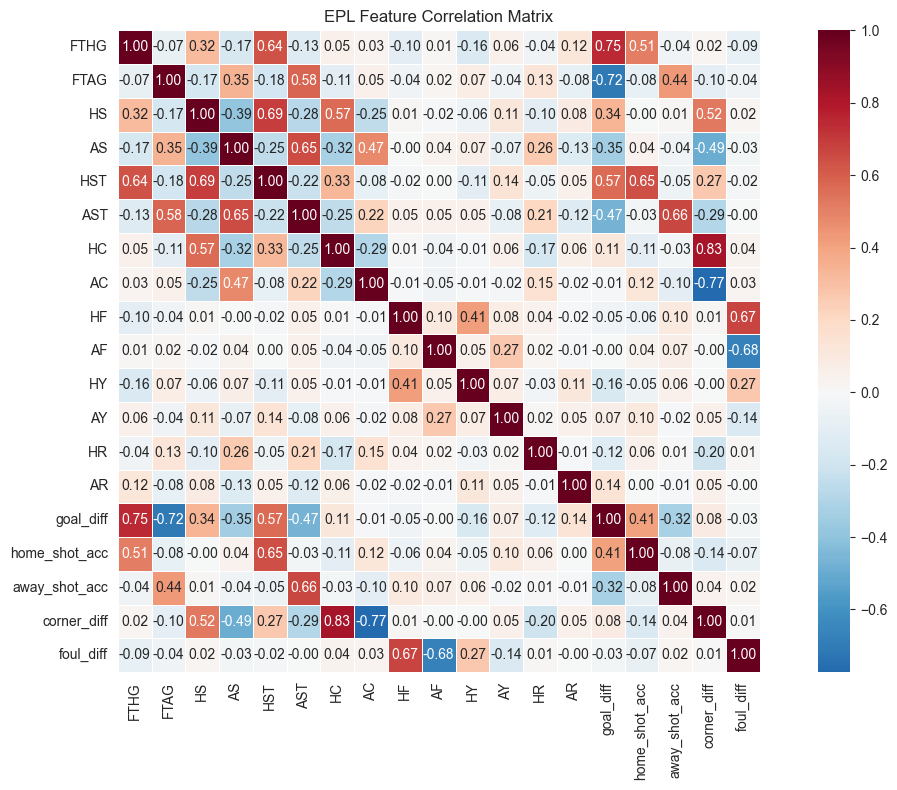

In [20]:
# Correlation Heatmap
corr = df_clean_epl[epl_all_features].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5)
plt.title('EPL Feature Correlation Matrix')
plt.tight_layout()
plt.show()

In [21]:
# Train / Val / Test Split (70 / 15 / 15)
le_epl = LabelEncoder()
y_epl = le_epl.fit_transform(df_clean_epl['FTR'])
X_epl = df_clean_epl[epl_all_features]

print(f'Class mapping: {dict(zip(le_epl.classes_, le_epl.transform(le_epl.classes_)))}')

X_epl_train, X_epl_temp, y_epl_train, y_epl_temp = train_test_split(
    X_epl, y_epl, test_size=0.30, random_state=42, stratify=y_epl)
X_epl_val, X_epl_test, y_epl_val, y_epl_test = train_test_split(
    X_epl_temp, y_epl_temp, test_size=0.50, random_state=42, stratify=y_epl_temp)

print(f'Train : {X_epl_train.shape}')
print(f'Val   : {X_epl_val.shape}')
print(f'Test  : {X_epl_test.shape}')

Class mapping: {'A': np.int64(0), 'D': np.int64(1), 'H': np.int64(2)}
Train : (266, 19)
Val   : (57, 19)
Test  : (57, 19)


In [22]:
# บันทึก Clean Data และ Splits
df_clean_epl.to_csv('../data/processed/epl_clean.csv', index=False)
print('✓ Saved: ../data/processed/epl_clean.csv')

splits_epl = {
    'X_train': X_epl_train, 'X_val': X_epl_val, 'X_test': X_epl_test,
    'y_train': y_epl_train, 'y_val': y_epl_val, 'y_test': y_epl_test,
    'feature_cols': epl_all_features,
    'label_encoder': le_epl
}
joblib.dump(splits_epl, '../data/processed/epl_splits.pkl')
print('✓ Saved: ../data/processed/epl_splits.pkl')
print('\n=== Phase 1 Complete! ===')

✓ Saved: ../data/processed/epl_clean.csv
✓ Saved: ../data/processed/epl_splits.pkl

=== Phase 1 Complete! ===
